# Download K2 Variable Stars Data from Campaigns

In [8]:
import lightkurve as lk
from lightkurve import search_lightcurve
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline


In [12]:
df = pd.read_csv(r"../assets/k2-variable-campaigns/hlsp_k2varcat_k2_lightcurve_c00-c04_kepler_v2_catalog.csv")


In [13]:
df


,# ID,Campaign,Class,Class Probs (DSCUT,EA,EB,GDOR,Noise,OTHPER,RRab),Anomaly Score
0,202059070,0,Noise,0.004195,0.120507,0.016615,0.005925,0.604636,0.246088,0.002034,0.023891
1,202059073,0,Noise,0.000000,0.000760,0.000037,0.000180,0.851359,0.147664,0.000000,0.003344
2,202059074,0,Noise,0.000086,0.003688,0.000218,0.007253,0.547118,0.441569,0.000067,0.083032
3,202059078,0,Noise,0.000523,0.002839,0.000332,0.000105,0.888648,0.107552,0.000000,0.000000
4,202059080,0,Noise,0.038219,0.082267,0.022758,0.058409,0.614507,0.078915,0.104926,0.136364
...,...,...,...,...,...,...,...,...,...,...,...
68905,211201576,4,OTHPER,0.000779,0.030250,0.003867,0.006026,0.399292,0.559605,0.000182,0.003344
68906,211202722,4,Noise,0.001130,0.066439,0.018303,0.010098,0.613187,0.290660,0.000183,0.003344
68907,211203438,4,Noise,0.003991,0.280059,0.017429,0.017574,0.482890,0.198004,0.000052,0.006711
68908,211203556,4,Noise,0.005440,0.087409,0.009792,0.031328,0.604436,0.261294,0.000302,0.010101


In [4]:
from astropy.io import fits

hdul = fits.open("../assets/data/test-variable-lc.fits")
hdul.info()


Filename: ../assets/data/test-variable-lc.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      67   ()      
  1                1 BinTableHDU     26   1454R x 5C   [D, E, E, E, E]   


In [5]:
hdul


[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x16aed92b0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x16aed9550>]

In [6]:
# Light curve data is usually in extension 1
data = hdul[1].data
data


FITS_rec([(1940.0280118 , 1233.5972, 26.70977 , 1.0284357, 0.02082971),
          (1940.04844349, 1226.5762, 25.792166, 1.00699  , 0.01969468),
          (1940.06887498, 1218.72  , 27.040632, 1.0333587, 0.02118868),
          ...,
          (1972.14664745, 1330.897 , 28.884472, 1.0016643, 0.02193929),
          (1972.16707924, 1332.01  , 29.98771 , 1.015696 , 0.02309633),
          (1972.18751114, 1319.3499, 30.731415, 1.0077314, 0.02348353)],
         dtype=(numpy.record, [('TIME', '>f8'), ('APTFLUX', '>f4'), ('APTFLUX_ERR', '>f4'), ('DETFLUX', '>f4'), ('DETFLUX_ERR', '>f4')]))

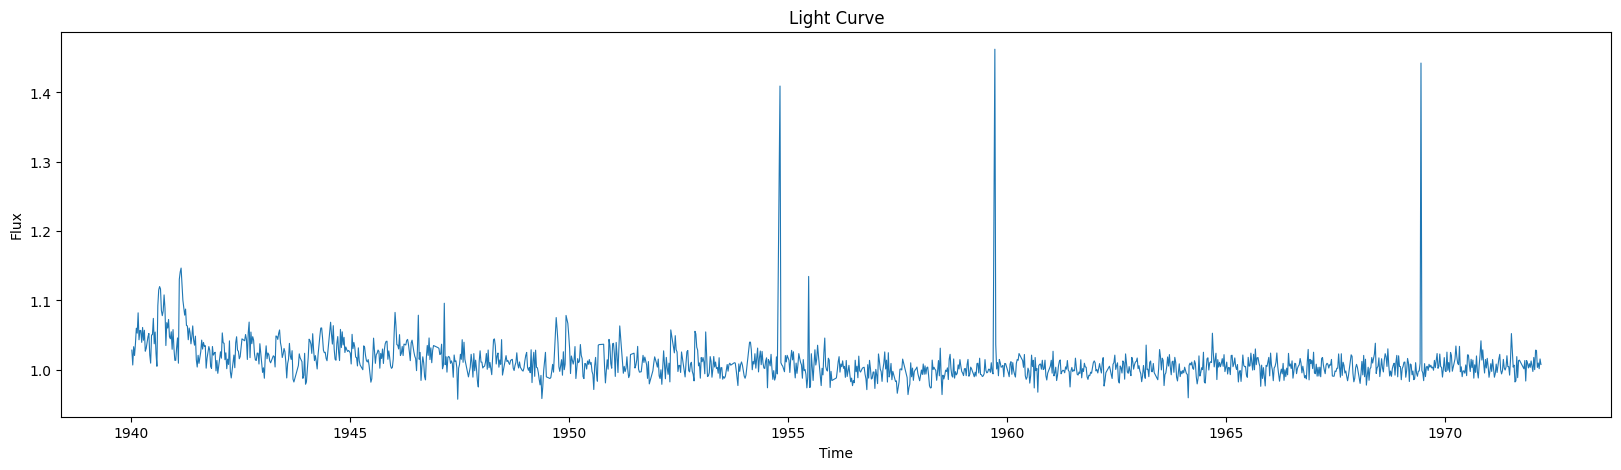

In [15]:
time = data["TIME"]
flux = data["DETFLUX"]       # or data["APTFLUX"]
flux_err = data["DETFLUX_ERR"]  # or data["APTFLUX_ERR"]

mask = np.isfinite(time) & np.isfinite(flux)
if flux_err is not None:
    mask &= np.isfinite(flux_err)

time = time[mask]
flux = flux[mask]
flux_err = flux_err[mask]

plt.figure(figsize=(20, 5))
plt.plot(time, flux, linewidth=0.8)
plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("Light Curve")
plt.show()
